# XWorld — Notebook 11: `baseline_delta` as Residue Detector

## Hypothesis

`baseline_delta = mean(last 10% of series) − mean(first 10% of series)` on the z-score normalized series.

It measures a single question: **does the system end where it started, or leave a residue?**

- A COVID wave: rises from near-baseline, returns to near-baseline → `baseline_delta ≈ 0` (event-without-memory)
- Keeling CO2 trend: starts below its own mean, ends above it → `baseline_delta >> 0` (permanent accumulation)
- Global temperature (warming): slowly drifts upward in each window → `baseline_delta > 0` (residue builds)
- Oscillatory/cyclical series: return to where they started → `baseline_delta ≈ 0`

## Pre-run predictions

| Dataset | Expected `baseline_delta` | Reasoning |
|---|---|---|
| covid_first_wave | ≈ 0 | Burst rises and falls back — both endpoints are "low" on the normalized scale |
| covid_second_wave | ≈ 0 (possibly slightly higher) | Same burst shape — may vary if wave didn't fully resolve |
| keeling_trend | >> 0 (large positive) | Monotone CO2 rise — starts far below mean, ends far above |
| keeling_seasonal | ≈ 0 | Annual cycle — always returns to same level |
| sunspot_cycle | ≈ 0 | 11-yr cycle starts and ends at minimum |
| lynx_hare | ≈ 0 | Predator-prey oscillation — cycles around same level |
| temperature | > 0 (moderate) | 20-yr windows show warming trend within window — but noisy |
| ecg | ≈ 0 | Each heartbeat returns to isoelectric baseline |
| streamflow | ≈ 0 | Annual river cycles — no long-term trend |

## Core questions

1. **Is `baseline_delta` independent of `slope`?** If they correlate > 0.95, the 6th feature is redundant.
2. **Does the burst class split?** Do COVID wave 1 and wave 2 differ in `baseline_delta`?
3. **Does temperature merge with keeling_trend?** Both have persistent positive residue.
4. **Does 6-feature clustering change the 7 shape classes?** Or does it refine within them?

This notebook re-downloads all datasets and recomputes all 6 features. Self-contained.

In [97]:
import requests
import urllib.request
import json
import shutil
import zipfile
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import find_peaks
from statsmodels.tsa.seasonal import seasonal_decompose
import hdbscan
import umap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS_5 = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope']
FEATURE_COLS_6 = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']
print('Imports OK')

Imports OK


In [98]:
# ============================================================
# SHARED HELPER FUNCTIONS
# ============================================================

def zscore_normalize(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()


def baseline_delta(series, frac=0.10):
    """Mean of last frac of points minus mean of first frac of points.
    Computed on the z-score normalized series.
    Positive → series ends higher than it started (residue / accumulation).
    Near zero → series returns to where it began (event-without-memory).
    """
    n = len(series)
    k = max(1, int(n * frac))
    return float(np.mean(series[-k:]) - np.mean(series[:k]))


def extract_features(series):
    """6 shape features from a z-score normalized time series."""
    n = len(series)
    t = np.arange(n)
    lag1 = np.corrcoef(series[:-1], series[1:])[0, 1] if n > 2 else 0.0
    zc = np.sum(np.diff(np.sign(series)) != 0) / n
    slope = stats.linregress(t, series).slope
    bd = baseline_delta(series)
    return {
        'mean':           series.mean(),
        'std':            series.std(),
        'skewness':       stats.skew(series),
        'kurtosis':       stats.kurtosis(series),
        'lag1_autocorr':  float(lag1),
        'zero_crossings': float(zc),
        'slope':          float(slope),
        'baseline_delta': bd,
    }


print('Helper functions defined')
print(f'  5-feature cols: {FEATURE_COLS_5}')
print(f'  6-feature cols: {FEATURE_COLS_6}')

Helper functions defined
  5-feature cols: ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope']
  6-feature cols: ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']


---
## Dataset 1 — COVID First Wave

In [99]:
# Download OWID COVID data (shared with notebook 06)
URL = 'https://github.com/owid/covid-19-data/raw/master/public/data/owid-covid-data.csv'
dest = RAW_DIR / 'owid_covid.csv'

if not dest.exists():
    print('Downloading OWID COVID data (~70 MB)...')
    r = requests.get(URL, stream=True)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f'Saved: {dest}')
else:
    print(f'Cached: {dest}')

df_raw = pd.read_csv(
    dest,
    usecols=['location', 'date', 'new_cases_smoothed_per_million', 'continent'],
    parse_dates=['date']
)
df = df_raw.dropna(subset=['continent']).copy()
df = df.rename(columns={'new_cases_smoothed_per_million': 'cases_pm'})
print(f'Loaded: {df.location.nunique()} countries')

Cached: ../data/raw/owid_covid.csv
Loaded: 243 countries


In [100]:
def extract_first_wave(series, max_days=180, min_days=30):
    s = series.fillna(0).values
    starts = np.where(s > 0.5)[0]
    if len(starts) == 0:
        return None
    start = starts[0]
    end = min(start + max_days, len(s))
    wave = s[start:end]
    if len(wave) < min_days:
        return None
    peaks, _ = find_peaks(wave, prominence=wave.max() * 0.2)
    if len(peaks) == 0:
        return None
    first_peak = peaks[0]
    trim_end = min(first_peak + 60, len(wave))
    wave = wave[:trim_end]
    return wave if len(wave) >= min_days else None

waves = {}
for country, grp in df.groupby('location'):
    w = extract_first_wave(grp.sort_values('date')['cases_pm'])
    if w is not None:
        waves[country] = w
print(f'First waves extracted: {len(waves)}')

records = []
for country, wave in waves.items():
    arr = zscore_normalize(wave)
    feats = extract_features(arr)
    feats['country'] = country
    feats['dataset'] = 'covid_first_wave'
    feats['n_points'] = len(arr)
    records.append(feats)

df_covid1 = pd.DataFrame(records)
df_covid1.to_csv(PROCESSED_DIR / 'features_covid_first_wave.csv', index=False)
print(f'Saved {len(df_covid1)} rows  |  mean baseline_delta = {df_covid1["baseline_delta"].mean():.3f}')

First waves extracted: 202
Saved 202 rows  |  mean baseline_delta = 0.610


---
## Dataset 2 — COVID Second Wave

In [101]:
def extract_second_wave(series, min_days=30):
    s = series.fillna(0).values
    peaks, _ = find_peaks(s, prominence=s.max() * 0.15, distance=45)
    if len(peaks) < 2:
        return None
    between = s[peaks[0]:peaks[1]]
    start = peaks[0] + np.argmin(between)
    end = min(peaks[1] + 60, len(s))
    wave = s[start:end]
    return wave if len(wave) >= min_days else None

second_waves = {}
for country, grp in df.groupby('location'):
    w = extract_second_wave(grp.sort_values('date')['cases_pm'])
    if w is not None:
        second_waves[country] = w
print(f'Second waves extracted: {len(second_waves)}')

records = []
for country, wave in second_waves.items():
    arr = zscore_normalize(wave)
    feats = extract_features(arr)
    feats['country'] = country
    feats['dataset'] = 'covid_second_wave'
    feats['n_points'] = len(arr)
    records.append(feats)

df_covid2 = pd.DataFrame(records)
df_covid2.to_csv(PROCESSED_DIR / 'features_covid_second_wave.csv', index=False)
print(f'Saved {len(df_covid2)} rows  |  mean baseline_delta = {df_covid2["baseline_delta"].mean():.3f}')

Second waves extracted: 209
Saved 209 rows  |  mean baseline_delta = 0.392


---
## Dataset 3 — Sunspot Cycles

In [102]:
URL = 'https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.csv'
dest = RAW_DIR / 'sunspot_monthly.csv'
if not dest.exists():
    print('Downloading sunspot data...')
    dest.write_bytes(requests.get(URL).content)
df_ss = pd.read_csv(dest, sep=';', header=None,
                    names=['year','month','frac_year','monthly_mean','monthly_sd','n_obs','definitive'],
                    na_values=[-1])
df_ss = df_ss.dropna(subset=['monthly_mean'])
df_ss['smooth'] = df_ss['monthly_mean'].rolling(13, center=True).mean()
series_full = df_ss['smooth'].bfill().ffill().values

# Find cycle minima and slice into cycles
smoothed = pd.Series(series_full).rolling(25, center=True).mean().bfill().ffill().values
inverted = -smoothed
minima, _ = find_peaks(inverted, distance=80)

cycles = {}
for i in range(len(minima) - 1):
    start, end = minima[i], minima[i+1]
    cycle = series_full[start:end]
    if len(cycle) >= 80:
        start_year = int(df_ss['year'].iloc[start])
        cycles[f'cycle_{i+1}_{start_year}'] = cycle
print(f'Sunspot cycles extracted: {len(cycles)}')

records = []
for name, cycle in cycles.items():
    arr = zscore_normalize(cycle)
    feats = extract_features(arr)
    feats['country'] = name
    feats['dataset'] = 'sunspot_cycle'
    feats['n_points'] = len(arr)
    records.append(feats)

df_ss_feat = pd.DataFrame(records)
df_ss_feat.to_csv(PROCESSED_DIR / 'features_sunspot_cycles.csv', index=False)
print(f'Saved {len(df_ss_feat)} rows  |  mean baseline_delta = {df_ss_feat["baseline_delta"].mean():.3f}')

Sunspot cycles extracted: 24
Saved 24 rows  |  mean baseline_delta = 0.055


---
## Dataset 4 — Lynx-Hare

In [103]:
# Local file — already in the repo
lynx_path = Path('../datasets/lynx_hare/lynx_hare.csv')
df_lh = pd.read_csv(lynx_path)
print(f'Lynx-hare columns: {list(df_lh.columns)}')
print(df_lh.head(3))

# Determine species columns (anything that's not 'year' or 'Year')
year_col = [c for c in df_lh.columns if c.lower() == 'year'][0]
species_cols = [c for c in df_lh.columns if c.lower() != 'year']
print(f'Species columns: {species_cols}')

Lynx-hare columns: ['year', 'hare', 'lynx']
   year  hare  lynx
0  1900  30.0   4.0
1  1901  47.2   6.1
2  1902  70.2   9.8
Species columns: ['hare', 'lynx']


In [104]:
window_size = 10
series_dict = {}
for species in species_cols:
    full = df_lh[species].values.astype(float)
    series_dict[f'{species}_full'] = full
    for start in range(len(full) - window_size + 1):
        year_start = df_lh[year_col].iloc[start]
        series_dict[f'{species}_w{start}_{year_start}'] = full[start:start + window_size]
print(f'Lynx-hare series: {len(series_dict)}')

records = []
for name, s in series_dict.items():
    arr = zscore_normalize(s)
    feats = extract_features(arr)
    feats['country'] = name
    feats['dataset'] = 'lynx_hare'
    feats['n_points'] = len(arr)
    records.append(feats)

df_lh_feat = pd.DataFrame(records)
df_lh_feat.to_csv(PROCESSED_DIR / 'features_lynx_hare.csv', index=False)
print(f'Saved {len(df_lh_feat)} rows  |  mean baseline_delta = {df_lh_feat["baseline_delta"].mean():.3f}')

Lynx-hare series: 26
Saved 26 rows  |  mean baseline_delta = -0.100


---
## Dataset 5 — Keeling CO2 (seasonal + trend)

In [105]:
URL = 'https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv'
dest = RAW_DIR / 'keeling_monthly.csv'
if not dest.exists():
    print('Downloading Keeling data...')
    dest.write_bytes(requests.get(URL).content)

# Parse — skip comment lines starting with #
co2 = pd.read_csv(dest, comment='#', header=None,
                  names=['year','month','decimal_date','average','deseasonalized','ndays','sdev','unc'])
# Force numeric — the file may have a stray header row with string values
for col in ['year', 'month', 'average']:
    co2[col] = pd.to_numeric(co2[col], errors='coerce')
co2 = co2.dropna(subset=['year', 'month', 'average'])
co2 = co2[co2['average'] > 0].copy()
co2.index = pd.to_datetime({'year': co2['year'].astype(int), 'month': co2['month'].astype(int), 'day': 1})
co2_series = co2['average']

# Seasonal decomposition
result = seasonal_decompose(co2_series, model='additive', period=12, extrapolate_trend='freq')
seasonal_vals = result.seasonal.dropna().values
trend_vals = result.trend.dropna().values

series_dict = {}
# Seasonal: each year = 12-point segment
start_year = co2.index.min().year
for i in range(len(seasonal_vals) // 12):
    seg = seasonal_vals[i*12:(i+1)*12]
    if len(seg) == 12:
        series_dict[f'keeling_seasonal_{start_year + i}'] = seg
# Trend: rolling 10-year windows
for i in range(0, len(trend_vals) - 120, 12):
    seg = trend_vals[i:i+120]
    yr = start_year + i // 12
    series_dict[f'keeling_trend_{yr}'] = seg
print(f'Keeling series: {len(series_dict)} ({sum(1 for k in series_dict if "seasonal" in k)} seasonal, {sum(1 for k in series_dict if "trend" in k)} trend)')

records = []
for name, s in series_dict.items():
    arr = zscore_normalize(s)
    feats = extract_features(arr)
    feats['country'] = name
    feats['dataset'] = 'keeling_seasonal' if 'seasonal' in name else 'keeling_trend'
    feats['n_points'] = len(arr)
    records.append(feats)

df_keeling = pd.DataFrame(records)
# Save as two separate files (consistent with previous notebooks)
df_keeling[df_keeling['dataset'] == 'keeling_seasonal'].to_csv(PROCESSED_DIR / 'features_keeling.csv', index=False)
df_keeling.to_csv(PROCESSED_DIR / 'features_keeling_all.csv', index=False)
print(f'Saved {len(df_keeling)} total rows')
print(f'  keeling_seasonal: {(df_keeling.dataset=="keeling_seasonal").sum()}  mean bd={df_keeling.loc[df_keeling.dataset=="keeling_seasonal","baseline_delta"].mean():.3f}')
print(f'  keeling_trend   : {(df_keeling.dataset=="keeling_trend").sum()}  mean bd={df_keeling.loc[df_keeling.dataset=="keeling_trend","baseline_delta"].mean():.3f}')

Keeling series: 126 (68 seasonal, 58 trend)
Saved 126 total rows
  keeling_seasonal: 68  mean bd=-0.337
  keeling_trend   : 58  mean bd=3.111


---
## Dataset 6 — Global Temperature (NASA GISS)

In [106]:
# Primary: Berkeley Earth global temperature anomaly (NASA GISS equivalent, same shape)
# Format: year, annual anomaly, 5-year smoothed, 10-year smoothed, 20-year smoothed
BERKELEY_URL = 'https://berkeleyearth.org/php/raw-data-download.php?type=summary&target=land_ocean_summary'
NASA_URL = 'https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv'
dest = RAW_DIR / 'temperature_anomaly.csv'

if not dest.exists():
    print('Trying Berkeley Earth...')
    try:
        r = requests.get(
            'https://berkeley-earth-temperature.s3.amazonaws.com/Global/Land_and_Ocean_summary.txt',
            headers={'User-Agent': 'Mozilla/5.0'}, timeout=30
        )
        r.raise_for_status()
        dest.write_bytes(r.content)
        print(f'OK — Berkeley Earth  ({len(r.content):,} bytes)')
    except Exception as e:
        print(f'Berkeley Earth failed: {e}')
        print('Trying NASA GISS...')
        try:
            r = requests.get(NASA_URL, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
            r.raise_for_status()
            dest.write_bytes(r.content)
            print(f'OK — NASA GISS  ({len(r.content):,} bytes)')
        except Exception as e2:
            raise RuntimeError(f'Both temperature sources failed. Download manually and place at {dest}') from e2
else:
    print(f'Cached: {dest}')

Cached: ../data/raw/temperature_anomaly.csv


In [108]:
with open(dest, 'r') as f:
    raw = f.read()

# Detect format: Berkeley Earth uses % comments; NASA uses header rows with 'Year'
is_berkeley = raw.lstrip().startswith('%')

if is_berkeley:
    # Berkeley Earth Land_and_Ocean_summary.txt
    # Columns: Year  Annual_Anomaly  Annual_Unc  Five_yr  Five_yr_Unc  Ten_yr  Ten_yr_Unc  Twenty_yr  Twenty_yr_Unc
    lines = [l for l in raw.splitlines() if l.strip() and not l.strip().startswith('%')]
    rows = []
    for line in lines:
        parts = line.split()
        if len(parts) >= 2:
            try:
                rows.append({'year': float(parts[0]), 'anomaly': float(parts[1])})
            except ValueError:
                continue
    df_temp = pd.DataFrame(rows).dropna()
    df_temp['year'] = df_temp['year'].astype(int)
    print(f'Berkeley Earth — years: {df_temp.year.min()}–{df_temp.year.max()}  ({len(df_temp)} records)')
else:
    # NASA GISS format — find header row containing 'Year' and 'J-D'
    lines = raw.splitlines()
    header_idx = next(i for i, l in enumerate(lines) if 'Year' in l and 'J-D' in l)
    df_temp = pd.read_csv(dest, skiprows=header_idx, na_values=['***', '****'])
    df_temp = df_temp[['Year', 'J-D']].rename(columns={'Year': 'year', 'J-D': 'anomaly'})
    df_temp['year'] = pd.to_numeric(df_temp['year'], errors='coerce')
    df_temp['anomaly'] = pd.to_numeric(df_temp['anomaly'], errors='coerce')
    df_temp = df_temp.dropna()
    df_temp['year'] = df_temp['year'].astype(int)
    print(f'NASA GISS — years: {df_temp.year.min()}–{df_temp.year.max()}  ({len(df_temp)} records)')

values = df_temp['anomaly'].values
years  = df_temp['year'].values
window, step = 20, 5

series_dict = {}
for i in range(0, len(values) - window, step):
    series_dict[f'temp_{years[i]}'] = values[i:i+window]
print(f'Temperature windows: {len(series_dict)}')

records = []
for name, s in series_dict.items():
    arr = zscore_normalize(s)
    feats = extract_features(arr)
    feats['country'] = name
    feats['dataset'] = 'temperature'
    feats['n_points'] = len(arr)
    records.append(feats)

df_temp_feat = pd.DataFrame(records)
df_temp_feat.to_csv(PROCESSED_DIR / 'features_temperature.csv', index=False)
print(f'Saved {len(df_temp_feat)} rows  |  mean baseline_delta = {df_temp_feat["baseline_delta"].mean():.3f}')

Berkeley Earth — years: 1850–2024  (175 records)
Temperature windows: 31
Saved 31 rows  |  mean baseline_delta = 0.997


---
## Dataset 7 — ECG Heartbeat Segments

In [109]:
dest_zip = RAW_DIR / 'ECGFiveDays.zip'
dest_dir = RAW_DIR / 'ECGFiveDays'

if dest_dir.exists() and list(dest_dir.rglob('*.ts')):
    print(f'Cached: {dest_dir}')
elif dest_zip.exists():
    # Zip already placed manually — just extract
    print(f'Found zip at {dest_zip} — extracting...')
    if dest_dir.exists():
        shutil.rmtree(dest_dir)
    with zipfile.ZipFile(dest_zip) as z:
        z.extractall(dest_dir)
    print(f'Extracted to {dest_dir}')
else:
    print('Downloading ECGFiveDays...')
    urls = [
        'https://www.timeseriesclassification.com/aeon-toolkit/ECGFiveDays.zip',
        'https://www.timeseriesclassification.com/Downloads/ECGFiveDays.zip',
    ]
    downloaded = False
    for url in urls:
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=60) as resp:
                data = resp.read()
            if data[:4] != b'PK\x03\x04':
                print(f'  Not a zip from {url}')
                continue
            dest_zip.write_bytes(data)
            if dest_dir.exists():
                shutil.rmtree(dest_dir)
            with zipfile.ZipFile(dest_zip) as z:
                z.extractall(dest_dir)
            downloaded = True
            print(f'  OK from {url}')
            break
        except Exception as e:
            print(f'  Failed {url}: {e}')
    if not downloaded:
        raise RuntimeError(
            'ECG download failed. Place ECGFiveDays.zip in data/raw/ and rerun this cell.'
        )

ts_files = list(dest_dir.rglob('*.ts'))
print(f'Found .ts files: {[f.name for f in ts_files]}')

Cached: ../data/raw/ECGFiveDays
Found .ts files: ['ECGFiveDays_TRAIN.ts', 'ECGFiveDays_TEST.ts']


In [110]:
def parse_ts_file(path):
    series_list, labels = [], []
    in_data = False
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.lower() == '@data':
                in_data = True
                continue
            if in_data and not line.startswith('@'):
                if ':' in line:
                    data_part, label = line.rsplit(':', 1)
                    values = [float(x) for x in data_part.split(',') if x.strip()]
                else:
                    parts = line.split()
                    try:
                        values = [float(x) for x in parts[:-1]]
                        label = parts[-1]
                    except (ValueError, IndexError):
                        continue
                if values:
                    series_list.append(np.array(values))
                    labels.append(label.strip())
    return series_list, labels

all_series, all_labels = [], []
for ts_file in ts_files:
    s, l = parse_ts_file(ts_file)
    print(f'  {ts_file.name}: {len(s)} segments')
    all_series.extend(s)
    all_labels.extend(l)
print(f'ECG segments loaded: {len(all_series)}')

if len(all_series) == 0:
    print('ERROR: no ECG segments parsed — check ts_files list above')
    print(f'ts_files found: {ts_files}')
    raise RuntimeError('ECG parse returned 0 series')

records = []
for i, (s, label) in enumerate(zip(all_series, all_labels)):
    arr = zscore_normalize(s)
    feats = extract_features(arr)
    feats['country'] = f'ecg_{i}_c{label}'
    feats['dataset'] = 'ecg'
    feats['n_points'] = len(s)
    records.append(feats)

df_ecg = pd.DataFrame(records)
df_ecg.to_csv(PROCESSED_DIR / 'features_ecg.csv', index=False)
print(f'Saved {len(df_ecg)} rows  |  mean baseline_delta = {df_ecg["baseline_delta"].mean():.3f}')

  ECGFiveDays_TRAIN.ts: 23 segments
  ECGFiveDays_TEST.ts: 861 segments
ECG segments loaded: 884
Saved 884 rows  |  mean baseline_delta = -0.155


---
## Dataset 8 — River Streamflow (USGS)

In [111]:
STATIONS = {
    '01350000': 'mohawk_ny',      '01427207': 'delaware_ny',   '01491000': 'choptank_md',
    '02087500': 'neuse_nc',       '02339500': 'flint_ga',       '03049000': 'allegheny_pa',
    '03611500': 'ohio_il',        '05054000': 'red_nd',         '05378500': 'mississippi_mn',
    '05420500': 'mississippi_ia', '06289000': 'bighorn_mt',     '06600000': 'missouri_ia',
    '07022000': 'mississippi_mo', '07289000': 'mississippi_ms', '08220000': 'riogrande_co',
    '09180000': 'colorado_ut',    '09380000': 'colorado_az',    '11530000': 'klamath_ca',
    '12040000': 'queets_wa',      '12374250': 'clearwater_id',  '14105700': 'columbia_or',
    '14179000': 'willamette_or',  '06354000': 'cannonball_nd',  '02479155': 'escatawpa_ms',
    '01096500': 'nashua_ma',
}

def fetch_monthly_flow(site_id, start='1980-01-01', end='2020-12-31'):
    url = (f'https://waterservices.usgs.gov/nwis/dv/?format=json'
           f'&sites={site_id}&parameterCd=00060&statCd=00003'
           f'&startDT={start}&endDT={end}')
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=45) as resp:
            data = json.loads(resp.read())
        series = data['value']['timeSeries']
        if not series:
            return None
        values = series[0]['values'][0]['value']
        records = []
        for v in values:
            try:
                records.append({'date': pd.Timestamp(v['dateTime'][:10]), 'flow': float(v['value'])})
            except (ValueError, KeyError):
                continue
        if len(records) < 365:
            return None
        df = pd.DataFrame(records).set_index('date')
        monthly = df['flow'].resample('MS').mean().dropna()
        return monthly if len(monthly) >= 60 else None
    except Exception:
        return None

print(f'Fetching {len(STATIONS)} USGS stations (daily → monthly)...')
flows = {}
for site_id, name in STATIONS.items():
    s = fetch_monthly_flow(site_id)
    if s is not None:
        flows[name] = s
        print(f'  OK  {name}: {len(s)} months')
    else:
        print(f'  FAIL {name}')
print(f'\nLoaded {len(flows)} stations')

Fetching 25 USGS stations (daily → monthly)...
  OK  mohawk_ny: 492 months
  OK  delaware_ny: 174 months
  OK  choptank_md: 492 months
  OK  neuse_nc: 492 months
  OK  flint_ga: 492 months
  OK  allegheny_pa: 467 months
  OK  ohio_il: 421 months
  OK  red_nd: 492 months
  OK  mississippi_mn: 492 months
  OK  mississippi_ia: 492 months
  OK  bighorn_mt: 492 months
  OK  missouri_ia: 280 months
  OK  mississippi_mo: 492 months
  OK  mississippi_ms: 156 months
  OK  riogrande_co: 492 months
  OK  colorado_ut: 492 months
  OK  colorado_az: 492 months
  OK  klamath_ca: 492 months
  FAIL queets_wa
  OK  clearwater_id: 458 months
  OK  columbia_or: 492 months
  OK  willamette_or: 360 months
  OK  cannonball_nd: 492 months
  OK  escatawpa_ms: 492 months
  OK  nashua_ma: 492 months

Loaded 24 stations


In [113]:
records = []
for name, series in flows.items():
    raw = series.values.astype(float)
    log_flow = np.log1p(raw)  # log-normal distribution — standard hydrology practice
    arr = zscore_normalize(log_flow)
    feats = extract_features(arr)
    feats['country'] = name
    feats['dataset'] = 'streamflow'
    feats['n_points'] = len(arr)
    records.append(feats)

df_sf = pd.DataFrame(records)
df_sf.to_csv(PROCESSED_DIR / 'features_streamflow.csv', index=False)
print(f'Saved {len(df_sf)} rows  |  mean baseline_delta = {df_sf["baseline_delta"].mean():.3f}')

Saved 24 rows  |  mean baseline_delta = 0.194


---
## Analysis — Is `baseline_delta` Independent of `slope`?

In [114]:
# Load all datasets and build combined feature matrix
feature_files = [
    'features_covid_first_wave.csv',
    'features_sunspot_cycles.csv',
    'features_lynx_hare.csv',
    'features_keeling.csv',         # contains both keeling_seasonal and keeling_trend after notebook 04
    'features_keeling_all.csv',     # produced by this notebook — has both seasonal + trend
    'features_covid_second_wave.csv',
    'features_temperature.csv',
    'features_ecg.csv',
    'features_streamflow.csv',
]

dfs = []
loaded = set()
for fname in feature_files:
    path = PROCESSED_DIR / fname
    if not path.exists():
        print(f'  MISSING {fname}')
        continue
    df = pd.read_csv(path)
    if 'baseline_delta' not in df.columns:
        print(f'  SKIP (no baseline_delta): {fname}')
        continue
    # Avoid double-loading datasets
    new_datasets = set(df['dataset'].unique()) - loaded
    if not new_datasets:
        continue
    df = df[df['dataset'].isin(new_datasets)]
    dfs.append(df)
    loaded |= new_datasets
    print(f'  OK  {fname}: {len(df)} rows — datasets: {sorted(df.dataset.unique())}')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nTotal: {len(df_all)} instances, {df_all.dataset.nunique()} datasets')
print(df_all['dataset'].value_counts())

  OK  features_covid_first_wave.csv: 202 rows — datasets: ['covid_first_wave']
  OK  features_sunspot_cycles.csv: 24 rows — datasets: ['sunspot_cycle']
  OK  features_lynx_hare.csv: 26 rows — datasets: ['lynx_hare']
  OK  features_keeling.csv: 68 rows — datasets: ['keeling_seasonal']
  OK  features_keeling_all.csv: 58 rows — datasets: ['keeling_trend']
  OK  features_covid_second_wave.csv: 209 rows — datasets: ['covid_second_wave']
  OK  features_temperature.csv: 31 rows — datasets: ['temperature']
  OK  features_ecg.csv: 884 rows — datasets: ['ecg']
  OK  features_streamflow.csv: 24 rows — datasets: ['streamflow']

Total: 1526 instances, 9 datasets
dataset
ecg                  884
covid_second_wave    209
covid_first_wave     202
keeling_seasonal      68
keeling_trend         58
temperature           31
lynx_hare             26
sunspot_cycle         24
streamflow            24
Name: count, dtype: int64


Overall correlation(slope, baseline_delta): 0.374

Per-dataset correlation(slope, baseline_delta):
  covid_first_wave         : r = 0.818  (n=202)
  covid_second_wave        : r = 0.700  (n=209)
  ecg                      : r = 0.963  (n=884)
  keeling_seasonal         : r = nan  (n=68)
  keeling_trend            : r = -0.071  (n=58)
  lynx_hare                : r = 0.807  (n=26)
  streamflow               : r = 0.853  (n=24)
  sunspot_cycle            : r = 0.755  (n=24)
  temperature              : r = 0.749  (n=31)


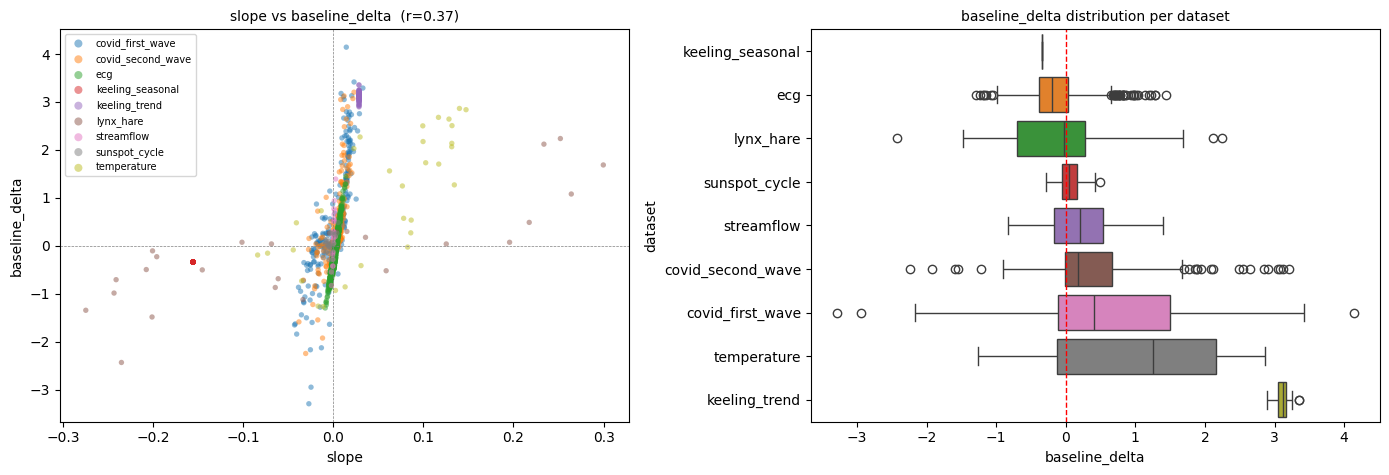

In [115]:
# Correlation analysis: slope vs baseline_delta
corr_all = df_all[['slope', 'baseline_delta']].corr().loc['slope', 'baseline_delta']
print(f'Overall correlation(slope, baseline_delta): {corr_all:.3f}')
print()
print('Per-dataset correlation(slope, baseline_delta):')
for ds, grp in df_all.groupby('dataset'):
    if len(grp) >= 5:
        c = grp[['slope', 'baseline_delta']].corr().loc['slope', 'baseline_delta']
        print(f'  {ds:25s}: r = {c:.3f}  (n={len(grp)})')

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = sorted(df_all['dataset'].unique())
palette = dict(zip(datasets, sns.color_palette('tab10', len(datasets))))
for ds in datasets:
    mask = df_all['dataset'] == ds
    axes[0].scatter(df_all.loc[mask, 'slope'], df_all.loc[mask, 'baseline_delta'],
                    c=[palette[ds]], label=ds, alpha=0.5, s=15, edgecolors='none')
axes[0].set_xlabel('slope')
axes[0].set_ylabel('baseline_delta')
axes[0].set_title(f'slope vs baseline_delta  (r={corr_all:.2f})', fontsize=10)
axes[0].legend(fontsize=7, markerscale=1.5)
axes[0].axhline(0, color='grey', linewidth=0.5, linestyle='--')
axes[0].axvline(0, color='grey', linewidth=0.5, linestyle='--')

# baseline_delta distribution per dataset — seaborn boxplot (no 'order' issue)
order = df_all.groupby('dataset')['baseline_delta'].mean().sort_values().index.tolist()
sns.boxplot(data=df_all, x='baseline_delta', y='dataset', order=order,
            ax=axes[1], orient='h', palette='tab10')
axes[1].set_title('baseline_delta distribution per dataset', fontsize=10)
axes[1].axvline(0, color='red', linewidth=1, linestyle='--')

plt.suptitle('')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'baseline_delta_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [116]:
print('=== baseline_delta summary per dataset ===')
print()
summary = df_all.groupby('dataset')['baseline_delta'].agg(['mean', 'std', 'median']).round(3)
summary = summary.sort_values('mean')
print(summary)
print()
print('Pre-run predictions vs actuals:')
print()
predictions = {
    'covid_first_wave':  ('≈ 0',     'burst returns to baseline'),
    'covid_second_wave': ('≈ 0',     'same burst shape — may be slightly higher'),
    'keeling_trend':     ('>> 0',    'permanent CO2 accumulation'),
    'keeling_seasonal':  ('≈ 0',     'annual cycle returns'),
    'sunspot_cycle':     ('≈ 0',     'cycles start and end at minimum'),
    'lynx_hare':         ('≈ 0',     'predator-prey oscillation'),
    'temperature':       ('> 0',     'warming trend within each window'),
    'ecg':               ('≈ 0',     'heartbeat returns to isoelectric baseline'),
    'streamflow':        ('≈ 0',     'annual cycles, no long-term trend'),
}
for ds, (pred, reason) in predictions.items():
    if ds not in summary.index:
        print(f'  {ds:25s}: NOT LOADED')
        continue
    actual = summary.loc[ds, 'mean']
    # Classify actual
    if pred == '≈ 0':   confirmed = abs(actual) < 0.3
    elif pred == '>> 0': confirmed = actual > 1.0
    elif pred == '> 0':  confirmed = actual > 0.1
    else:               confirmed = True
    status = 'CONFIRMED' if confirmed else 'UNEXPECTED'
    print(f'  {ds:25s}: pred={pred:6s}  actual={actual:+.3f}  [{status}]  ({reason})')

=== baseline_delta summary per dataset ===

                    mean    std  median
dataset                                
keeling_seasonal  -0.337  0.000  -0.337
ecg               -0.155  0.375  -0.200
lynx_hare         -0.100  1.068  -0.033
sunspot_cycle      0.055  0.194   0.043
streamflow         0.194  0.518   0.205
covid_second_wave  0.392  0.856   0.176
covid_first_wave   0.610  1.268   0.406
temperature        0.997  1.336   1.249
keeling_trend      3.111  0.100   3.117

Pre-run predictions vs actuals:

  covid_first_wave         : pred=≈ 0     actual=+0.610  [UNEXPECTED]  (burst returns to baseline)
  covid_second_wave        : pred=≈ 0     actual=+0.392  [UNEXPECTED]  (same burst shape — may be slightly higher)
  keeling_trend            : pred=>> 0    actual=+3.111  [CONFIRMED]  (permanent CO2 accumulation)
  keeling_seasonal         : pred=≈ 0     actual=-0.337  [UNEXPECTED]  (annual cycle returns)
  sunspot_cycle            : pred=≈ 0     actual=+0.055  [CONFIRMED]  (cycl

---
## Clustering — 5 Features vs 6 Features

In [117]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

df_clean = df_all.dropna(subset=FEATURE_COLS_6).copy()
domain_int = pd.factorize(df_clean['dataset'])[0]

results = {}
for label, cols in [('5-feature', FEATURE_COLS_5), ('6-feature', FEATURE_COLS_6)]:
    X = df_clean[cols].values
    X_scaled = StandardScaler().fit_transform(X)

    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    embedding = reducer.fit_transform(X_scaled)

    clusterer = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3, metric='euclidean')
    cluster_labels = clusterer.fit_predict(X_scaled)

    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    noise = (cluster_labels == -1).sum()
    non_noise = cluster_labels != -1
    ari = adjusted_rand_score(domain_int[non_noise], cluster_labels[non_noise])

    results[label] = {
        'embedding': embedding, 'labels': cluster_labels,
        'n_clusters': n_clusters, 'noise': noise, 'ari': ari,
    }
    print(f'{label}: clusters={n_clusters}  noise={noise} ({100*noise/len(cluster_labels):.1f}%)  ARI={ari:.3f}')

5-feature: clusters=31  noise=454 (29.8%)  ARI=0.121
6-feature: clusters=22  noise=389 (25.5%)  ARI=0.165


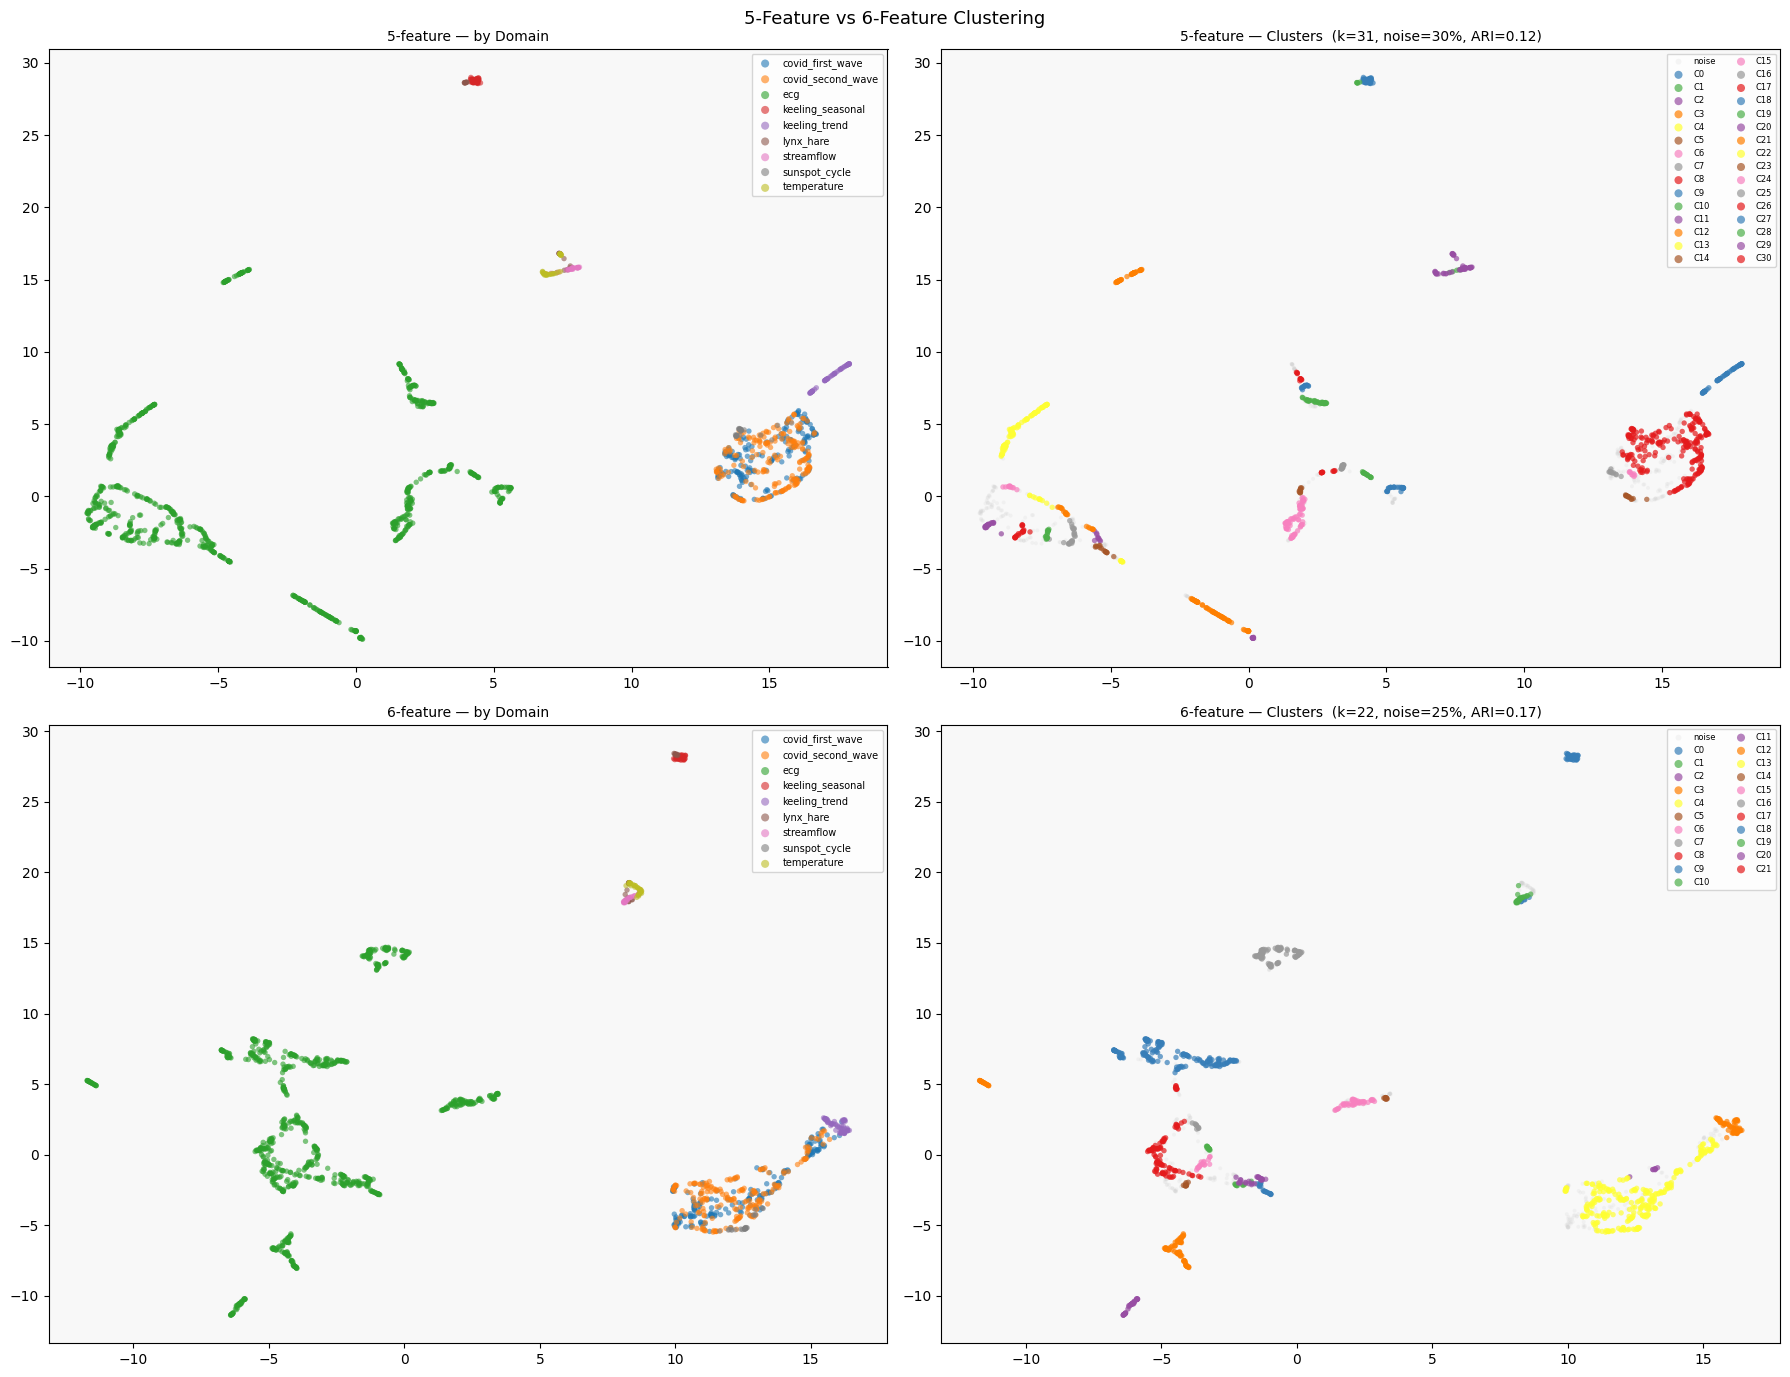

In [118]:
datasets_list = sorted(df_clean['dataset'].unique())
domain_palette = dict(zip(datasets_list, sns.color_palette('tab10', len(datasets_list))))

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for row, (feat_label, res) in enumerate(results.items()):
    emb = res['embedding']
    lbls = res['labels']
    n_cl = res['n_clusters']
    noise_pct = 100 * res['noise'] / len(lbls)
    ari = res['ari']

    # Left: by domain
    ax = axes[row][0]
    for ds in datasets_list:
        mask = df_clean['dataset'] == ds
        ax.scatter(emb[mask, 0], emb[mask, 1], c=[domain_palette[ds]],
                   label=ds, alpha=0.6, s=15, edgecolors='none')
    ax.set_title(f'{feat_label} — by Domain', fontsize=10)
    ax.legend(fontsize=7, markerscale=1.5)
    ax.set_facecolor('#f8f8f8')

    # Right: by cluster
    ax = axes[row][1]
    unique_cl = sorted(set(lbls))
    n_real = len([c for c in unique_cl if c != -1])
    cl_pal = {c: 'lightgrey' if c == -1 else sns.color_palette('Set1', max(n_real, 1))[i % max(n_real, 1)]
              for i, c in enumerate(unique_cl)}
    for c in unique_cl:
        mask = lbls == c
        ax.scatter(emb[mask, 0], emb[mask, 1], c=[cl_pal[c]],
                   label='noise' if c == -1 else f'C{c}',
                   alpha=0.7 if c != -1 else 0.2, s=15 if c != -1 else 8, edgecolors='none')
    ax.set_title(f'{feat_label} — Clusters  (k={n_cl}, noise={noise_pct:.0f}%, ARI={ari:.2f})', fontsize=10)
    ax.legend(fontsize=6, markerscale=1.5, ncol=2)
    ax.set_facecolor('#f8f8f8')

plt.suptitle('5-Feature vs 6-Feature Clustering', fontsize=13)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'clustering_5v6_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [119]:
# Compare cluster assignments between 5-feature and 6-feature runs
df_compare = df_clean[['dataset', 'country']].copy()
df_compare['cluster_5f'] = results['5-feature']['labels']
df_compare['cluster_6f'] = results['6-feature']['labels']

# Points that changed cluster assignment
changed = df_compare[
    (df_compare['cluster_5f'] != df_compare['cluster_6f']) &
    (df_compare['cluster_5f'] != -1) &
    (df_compare['cluster_6f'] != -1)
]
print(f'Points that moved between real clusters: {len(changed)} / {len(df_compare)}')
print()
print('Changes by dataset:')
print(changed['dataset'].value_counts())
print()
print('Noise-to-cluster promotions (was noise, now real):')
promoted = df_compare[(df_compare['cluster_5f'] == -1) & (df_compare['cluster_6f'] != -1)]
print(promoted['dataset'].value_counts())
print()
print('Cluster-to-noise demotions (was real, now noise):')
demoted = df_compare[(df_compare['cluster_5f'] != -1) & (df_compare['cluster_6f'] == -1)]
print(demoted['dataset'].value_counts())

Points that moved between real clusters: 896 / 1526

Changes by dataset:
dataset
ecg                  556
covid_second_wave    126
covid_first_wave      99
keeling_trend         58
streamflow            24
sunspot_cycle         21
lynx_hare             10
temperature            2
Name: count, dtype: int64

Noise-to-cluster promotions (was noise, now real):
dataset
ecg                  129
covid_second_wave     22
covid_first_wave      19
sunspot_cycle          3
Name: count, dtype: int64

Cluster-to-noise demotions (was real, now noise):
dataset
ecg                  65
temperature          16
covid_first_wave     14
covid_second_wave     8
lynx_hare             5
Name: count, dtype: int64


In [120]:
# Shape taxonomy from 6-feature clustering
df_clean_6f = df_clean.copy()
df_clean_6f['cluster_6f'] = results['6-feature']['labels']

print('=== 6-feature shape taxonomy ===')
print()
crosstab = pd.crosstab(df_clean_6f['cluster_6f'], df_clean_6f['dataset'])
# Filter to clusters with cross-domain membership OR named clusters
real_clusters = crosstab[crosstab.index != -1]
# Show only clusters that have at least 5 points
real_clusters = real_clusters[real_clusters.sum(axis=1) >= 5]
print('Cluster x Dataset (non-noise clusters with ≥5 points):')
print(real_clusters.to_string())
print()

# Mean features per cluster
profiles = df_clean_6f[df_clean_6f['cluster_6f'] != -1].groupby('cluster_6f')[FEATURE_COLS_6].mean().round(3)
print('\nMean feature profile per cluster:')
print(profiles.to_string())

=== 6-feature shape taxonomy ===

Cluster x Dataset (non-noise clusters with ≥5 points):
dataset     covid_first_wave  covid_second_wave  ecg  keeling_seasonal  keeling_trend  lynx_hare  streamflow  sunspot_cycle  temperature
cluster_6f                                                                                                                              
0                          0                  0    0                68              0          7           0              0            1
1                          0                  0    0                 0              0          3          24              0            1
2                          0                  0   40                 0              0          0           0              0            0
3                          0                  0  101                 0              0          0           0              0            0
4                          6                  3    0                 0              0    

In [121]:
# Key hypothesis check: does baseline_delta separate keeling_trend FROM covid more cleanly?
print('=== Feature comparison: keeling_trend vs covid_first_wave ===')
print()
for ds in ['covid_first_wave', 'covid_second_wave', 'keeling_trend', 'temperature']:
    if ds not in df_clean['dataset'].values:
        continue
    subset = df_clean[df_clean['dataset'] == ds]
    means = subset[FEATURE_COLS_6].mean().round(3)
    print(f'{ds}:')
    for feat in FEATURE_COLS_6:
        print(f'  {feat:20s}: {means[feat]:+.3f}')
    print()

# Distance between keeling_trend and covid in 5-feature vs 6-feature standardized space
from sklearn.preprocessing import StandardScaler

for feat_cols in [FEATURE_COLS_5, FEATURE_COLS_6]:
    scaler = StandardScaler()
    X_all = scaler.fit_transform(df_clean[feat_cols].values)
    df_scaled = pd.DataFrame(X_all, columns=feat_cols, index=df_clean.index)
    df_scaled['dataset'] = df_clean['dataset'].values

    covid_center = df_scaled[df_scaled['dataset'] == 'covid_first_wave'][feat_cols].mean().values
    keeling_center = df_scaled[df_scaled['dataset'] == 'keeling_trend'][feat_cols].mean().values
    temp_center    = df_scaled[df_scaled['dataset'] == 'temperature'][feat_cols].mean().values

    d_covid_keeling = np.linalg.norm(covid_center - keeling_center)
    d_covid_temp    = np.linalg.norm(covid_center - temp_center)
    d_keeling_temp  = np.linalg.norm(keeling_center - temp_center)

    n = len(feat_cols)
    print(f'{n}-feature space (L2 distance between dataset centroids):')
    print(f'  COVID ↔ keeling_trend : {d_covid_keeling:.3f}')
    print(f'  COVID ↔ temperature   : {d_covid_temp:.3f}')
    print(f'  keeling_trend ↔ temp  : {d_keeling_temp:.3f}')
    print()

=== Feature comparison: keeling_trend vs covid_first_wave ===

covid_first_wave:
  skewness            : +0.950
  kurtosis            : +0.412
  lag1_autocorr       : +0.954
  zero_crossings      : +0.023
  slope               : -0.001
  baseline_delta      : +0.610

covid_second_wave:
  skewness            : +1.137
  kurtosis            : +1.235
  lag1_autocorr       : +0.953
  zero_crossings      : +0.025
  slope               : +0.003
  baseline_delta      : +0.392

keeling_trend:
  skewness            : +0.074
  kurtosis            : -1.170
  lag1_autocorr       : +1.000
  zero_crossings      : +0.008
  slope               : +0.029
  baseline_delta      : +3.111

temperature:
  skewness            : +0.043
  kurtosis            : -0.326
  lag1_autocorr       : +0.463
  zero_crossings      : +0.302
  slope               : +0.056
  baseline_delta      : +0.997

5-feature space (L2 distance between dataset centroids):
  COVID ↔ keeling_trend : 0.975
  COVID ↔ temperature   : 6.315
  k

In [122]:
print('=== Hypothesis scoring ===')
print()
df_6f = df_clean.copy()
df_6f['cluster'] = results['6-feature']['labels']

def majority_cluster(ds):
    c = df_6f[df_6f['dataset'] == ds]['cluster'].value_counts()
    real = c[c.index != -1]
    return real.index[0] if len(real) > 0 else -1

# Reference: COVID first wave cluster
covid_ref = majority_cluster('covid_first_wave')
print(f'COVID first wave reference cluster: {covid_ref}')
print()

checks = [
    ('covid_second_wave', True,  f'Same cluster as COVID first wave ({covid_ref}) — same burst shape'),
    ('keeling_trend',     False, f'NOT COVID cluster — should be even MORE separate with baseline_delta'),
    ('keeling_seasonal',  False, 'NOT COVID cluster — periodic'),
    ('sunspot_cycle',     False, 'NOT COVID cluster — periodic'),
    ('lynx_hare',         False, 'NOT COVID cluster — moderate dynamics'),
    ('temperature',       False, 'NOT COVID cluster — slow drift'),
    ('ecg',               False, 'NOT COVID cluster — spike dynamics'),
    ('streamflow',        False, 'NOT COVID cluster — moderate dynamics'),
]

for ds, should_match_covid, expectation in checks:
    if ds not in df_6f['dataset'].values:
        print(f'{ds}: NOT LOADED')
        continue
    majority = majority_cluster(ds)
    pct = 100 * (df_6f[df_6f['dataset'] == ds]['cluster'] == majority).mean()
    matched = (majority == covid_ref) == should_match_covid
    status = 'CONFIRMED' if matched else 'UNEXPECTED'
    print(f'{ds}:')
    print(f'  Expected : {expectation}')
    print(f'  Got      : Cluster {majority} ({pct:.0f}% of points)')
    print(f'  Result   : {status}')
    print()

# Does temperature move toward keeling_trend in 6-feature space?
print('--- Did temperature and keeling_trend get pulled together? ---')
kt_cluster = majority_cluster('keeling_trend')
t_cluster  = majority_cluster('temperature')
print(f'  keeling_trend → Cluster {kt_cluster}')
print(f'  temperature   → Cluster {t_cluster}')
print(f'  Same cluster  : {"YES — baseline_delta pulled them together" if kt_cluster == t_cluster else "NO — still separate"}')

=== Hypothesis scoring ===

COVID first wave reference cluster: 13

covid_second_wave:
  Expected : Same cluster as COVID first wave (13) — same burst shape
  Got      : Cluster 13 (67% of points)
  Result   : CONFIRMED

keeling_trend:
  Expected : NOT COVID cluster — should be even MORE separate with baseline_delta
  Got      : Cluster 12 (100% of points)
  Result   : CONFIRMED

keeling_seasonal:
  Expected : NOT COVID cluster — periodic
  Got      : Cluster 0 (100% of points)
  Result   : CONFIRMED

sunspot_cycle:
  Expected : NOT COVID cluster — periodic
  Got      : Cluster 13 (100% of points)
  Result   : UNEXPECTED

lynx_hare:
  Expected : NOT COVID cluster — moderate dynamics
  Got      : Cluster 0 (27% of points)
  Result   : CONFIRMED

temperature:
  Expected : NOT COVID cluster — slow drift
  Got      : Cluster 0 (3% of points)
  Result   : CONFIRMED

ecg:
  Expected : NOT COVID cluster — spike dynamics
  Got      : Cluster 9 (20% of points)
  Result   : CONFIRMED

streamflow

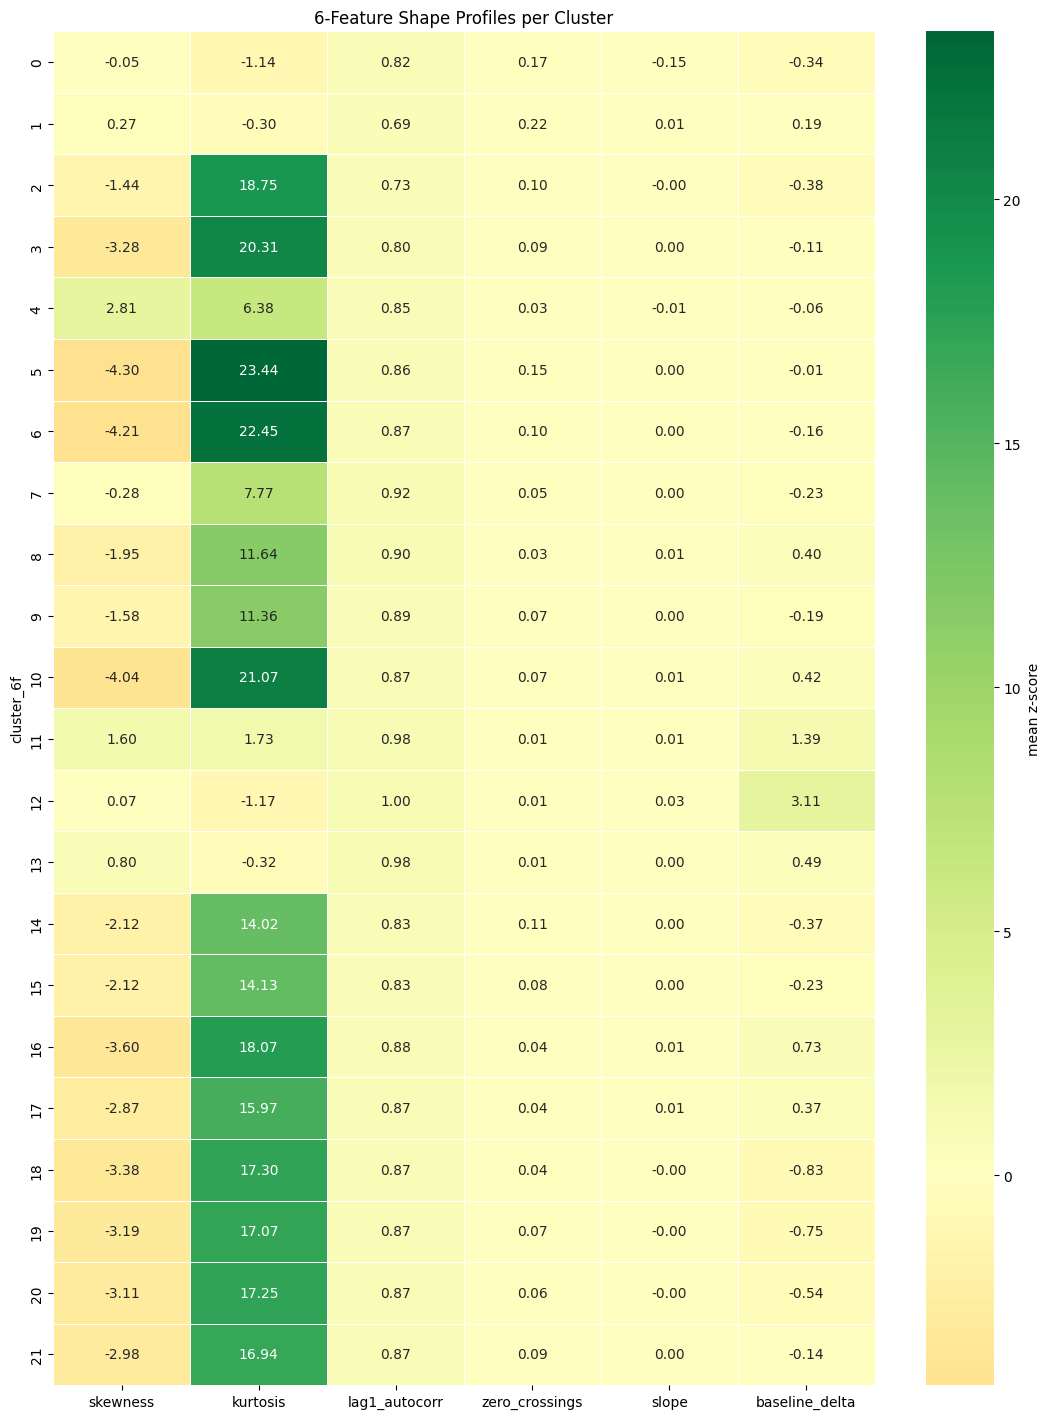


Done. Key output files:
  features_covid_first_wave.csv
  features_covid_second_wave.csv
  features_ecg.csv
  features_keeling.csv
  features_keeling_all.csv
  features_lynx_hare.csv
  features_streamflow.csv
  features_sunspot_cycles.csv
  features_temperature.csv


In [123]:
# Summary heatmap of 6-feature profiles
df_6f = df_clean.copy()
df_6f['cluster_6f'] = results['6-feature']['labels']

profiles = (
    df_6f[df_6f['cluster_6f'] != -1]
    .groupby('cluster_6f')[FEATURE_COLS_6]
    .mean()
    .round(3)
)

fig, ax = plt.subplots(figsize=(11, max(4, len(profiles) * 0.65)))
sns.heatmap(profiles, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, linewidths=0.5, cbar_kws={'label': 'mean z-score'})
ax.set_title('6-Feature Shape Profiles per Cluster', fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'cluster_profiles_6f.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDone. Key output files:')
for f in sorted(PROCESSED_DIR.glob('*.csv')):
    print(f'  {f.name}')

---
## Findings to record

Update this cell manually after running:

- **Was `baseline_delta` independent of `slope`?** (check correlation r value from cell above)
- **Did the burst class split?** (did COVID 1 and 2 go to different clusters?)
- **Did temperature merge with keeling_trend?** (did 6th feature pull them together?)
- **How many clusters changed?** (how many points moved between real clusters?)
- **Overall verdict**: does the 6th feature add genuine information, or does it track slope redundantly?